#Kütüphaneler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#1) Sentetik Housing Veri Setinin Üretilmesi

In [2]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    "Income": np.random.normal(50, 15, n),
    "HouseAge": np.random.normal(30, 8, n),
    "Rooms": np.random.normal(5, 1.5, n),
    "Population": np.random.normal(300, 120, n),
    "HouseValue": np.random.normal(200, 50, n)
})

# Bilinçli eksik değerler (ön işleme göstermek için)
df.loc[df.sample(frac=0.1, random_state=1).index, "Income"] = np.nan
df.loc[df.sample(frac=0.05, random_state=2).index, "Rooms"] = np.nan

df.head()

,Income,HouseAge,Rooms,Population,HouseValue
0,57.450712,37.409420,7.099033,393.403329,166.241086
1,47.926035,45.275333,NaN,233.857714,192.774066
2,59.715328,18.811459,5.089446,201.816134,160.379004
3,72.845448,34.503754,4.029595,299.595065,184.601924
4,NaN,24.794859,6.047335,279.577845,105.319267


In [3]:
df

,Income,HouseAge,Rooms,Population,HouseValue
0,57.450712,37.409420,7.099033,393.403329,166.241086
1,47.926035,45.275333,NaN,233.857714,192.774066
2,59.715328,18.811459,5.089446,201.816134,160.379004
3,72.845448,34.503754,4.029595,299.595065,184.601924
4,NaN,24.794859,6.047335,279.577845,105.319267
...,...,...,...,...,...
495,58.083651,27.751198,8.009139,428.418029,240.660259
496,34.441308,44.381492,8.092255,296.817449,186.051853
497,47.144920,35.126743,6.812549,194.175042,186.011992
498,36.865726,25.430568,6.536094,280.431964,239.518595


# 2) Veri Keşfi (EDA – Exploratory Data Analysis) #
 2.1 Veri Yapısı

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Income      450 non-null    float64
 1   HouseAge    500 non-null    float64
 2   Rooms       475 non-null    float64
 3   Population  500 non-null    float64
 4   HouseValue  500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


,Income,HouseAge,Rooms,Population,HouseValue
count,450.000000,500.000000,475.000000,500.000000,500.000000
mean,49.754206,30.254609,5.166993,303.982553,199.424182
std,14.590453,7.823978,1.515819,118.087935,47.978308
min,1.380990,8.424907,0.655617,-52.846636,49.024392
25%,39.274015,25.237666,4.091502,226.567661,166.963180
50%,49.978556,30.228253,5.179371,298.930396,199.842385
75%,59.170247,35.209938,6.148140,383.972329,233.458820
max,107.790972,51.059057,8.902525,683.172908,355.495928


2.2 Dağılım Analizi (Histogram)

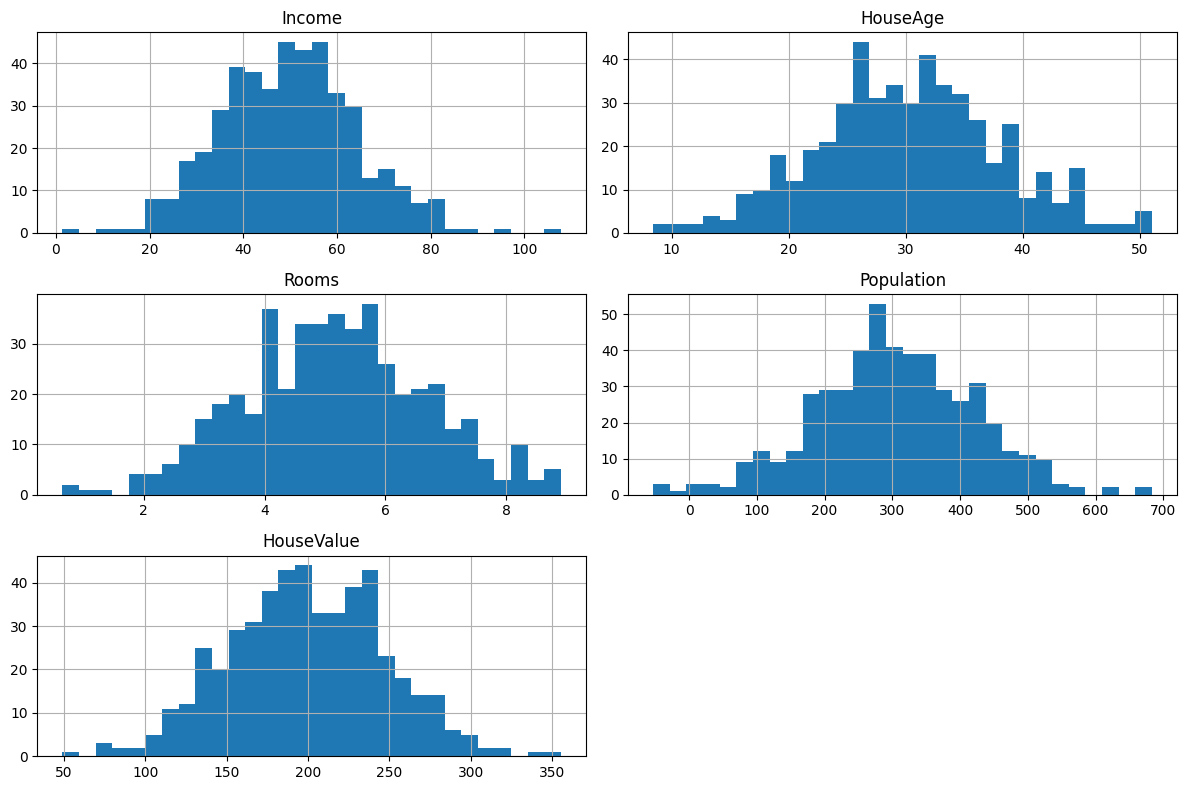

In [5]:
df.hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()


#3) Eksik Veri Analizi
3.1 Eksik Değer Sayıları

In [6]:
df.isna().sum()


,0
Income,50
HouseAge,0
Rooms,25
Population,0
HouseValue,0


3.2 Eksik Değerlerin Görselleştirilmesi

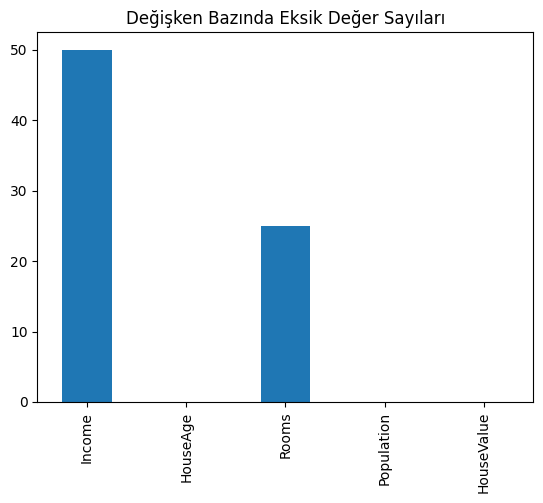

In [7]:
df.isna().sum().plot(kind="bar")
plt.title("Değişken Bazında Eksik Değer Sayıları")
plt.show()


# 4) Hedef Değişken Ayrımı #

In [8]:
X = df.drop("HouseValue", axis=1)
y = df["HouseValue"]

# 5) Eksik Verilerin Doldurulması (Imputation)

In [9]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(X_imputed, columns=X.columns)


In [10]:
X_imputed

,Income,HouseAge,Rooms,Population
0,57.450712,37.409420,7.099033,393.403329
1,47.926035,45.275333,5.179371,233.857714
2,59.715328,18.811459,5.089446,201.816134
3,72.845448,34.503754,4.029595,299.595065
4,49.978556,24.794859,6.047335,279.577845
...,...,...,...,...
495,58.083651,27.751198,8.009139,428.418029
496,34.441308,44.381492,8.092255,296.817449
497,47.144920,35.126743,6.812549,194.175042
498,36.865726,25.430568,6.536094,280.431964


# 6) Aykırı Değer (Outlier) Analizi
6.1 Boxplot ile İnceleme

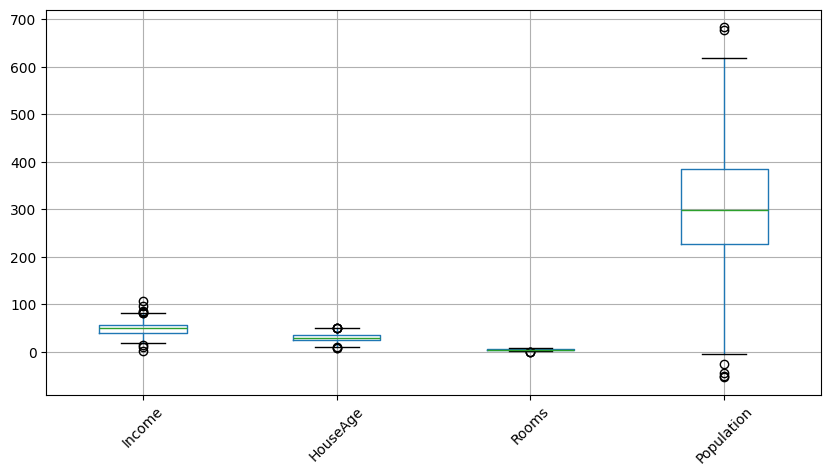

In [11]:
plt.figure(figsize=(10,5))
X_imputed.boxplot()
plt.xticks(rotation=45)
plt.show()

6.2 IQR (Interquartile Range) ile Tespit


In [12]:
Q1 = X_imputed.quantile(0.25)
Q3 = X_imputed.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ~(
    (X_imputed < (Q1 - 1.5 * IQR)) |
    (X_imputed > (Q3 + 1.5 * IQR))
).any(axis=1)

X_no_outliers = X_imputed[outlier_mask]
y_no_outliers = y[outlier_mask]

print("Önce:", X_imputed.shape)
print("Sonra:", X_no_outliers.shape)

Önce: (500, 4)
Sonra: (477, 4)


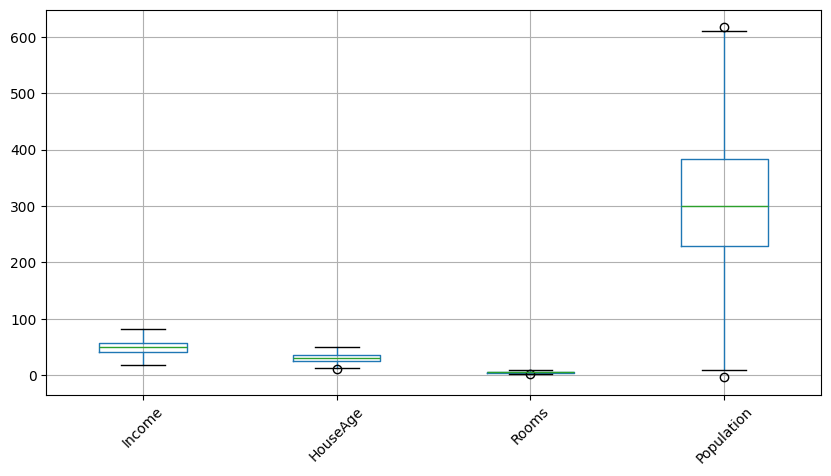

In [13]:
plt.figure(figsize=(10,5))
X_no_outliers.boxplot()
plt.xticks(rotation=45)
plt.show()

# 7) Ölçekleme (Scaling)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_outliers)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_no_outliers.columns,
    index=X_no_outliers.index
)


In [15]:
X_scaled

,Income,HouseAge,Rooms,Population
0,0.606642,0.958362,1.317339,0.786620
1,-0.136189,2.012350,-0.011538,-0.635109
2,0.783260,-1.533661,-0.073788,-0.920635
3,1.807280,0.569019,-0.807464,-0.049316
4,0.023888,-0.731919,0.589306,-0.227691
...,...,...,...,...
495,0.656005,-0.335786,1.947355,1.098640
496,-1.187865,1.892581,2.004891,-0.074067
497,-0.197108,0.652496,1.119022,-0.988725
498,-0.998784,-0.646737,0.927647,-0.220080


In [16]:
X_scaled.describe()


,Income,HouseAge,Rooms,Population
count,4.770000e+02,4.770000e+02,4.770000e+02,4.770000e+02
mean,2.755774e-16,-8.937644e-17,6.181871e-16,-4.431582e-16
std,1.001050e+00,1.001050e+00,1.001050e+00,1.001050e+00
min,-2.459085e+00,-2.632749e+00,-2.731007e+00,-2.751428e+00
25%,-6.664912e-01,-6.515168e-01,-7.087376e-01,-6.792491e-01
50%,2.388765e-02,-2.561590e-03,-1.153789e-02,-4.931562e-02
75%,6.273776e-01,6.609291e-01,6.250432e-01,6.989632e-01
max,2.533658e+00,2.597513e+00,2.565796e+00,2.781978e+00


# 8) Pipeline

In [ ]:
preprocess_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_pipeline_ready = preprocess_pipeline.fit_transform(X_no_outliers)

X_pipeline_ready = pd.DataFrame(
    X_pipeline_ready,
    columns=X_no_outliers.columns,
    index=X_no_outliers.index
)


In [ ]:
print("X shape:", X_pipeline_ready.shape)
print("y shape:", y_no_outliers.shape)


X shape: (477, 4)
y shape: (477,)
